In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df1 = pd.read_csv('final_train.csv')

df2=pd.read_csv('final_test.csv')
df = pd.concat([df,df2])
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (433564, 2)
Columns: ['text', 'label']


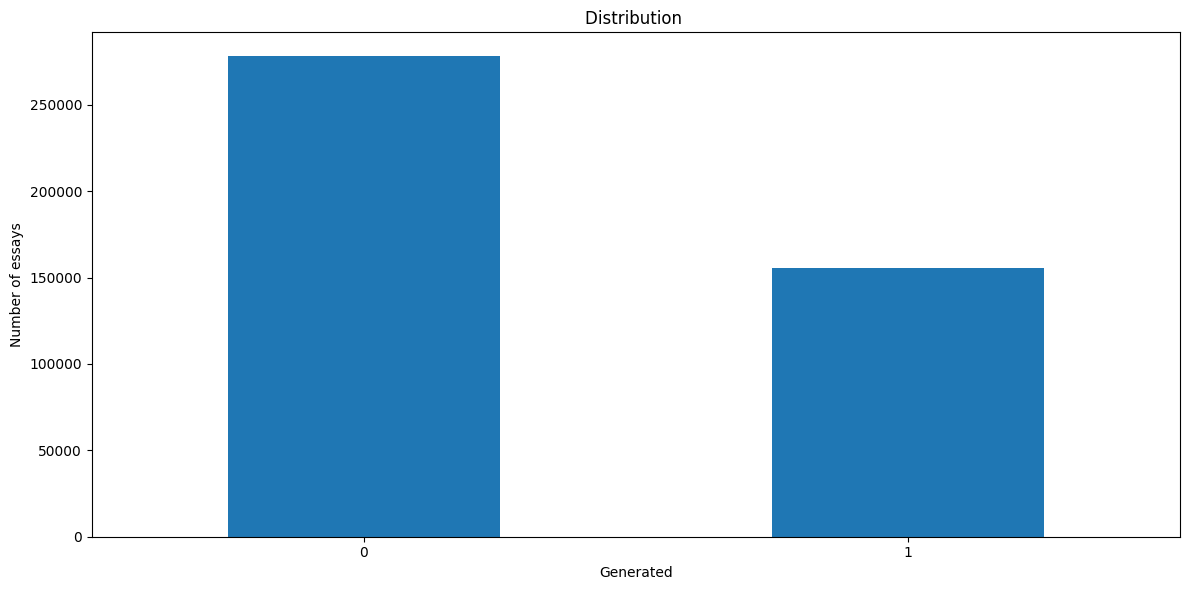

In [10]:
df.rename(columns={'label': 'generated'}, inplace=True)
category_counts = df['generated'].value_counts()

plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title('Distribution ')
plt.xlabel('Generated')
plt.ylabel('Number of essays')
plt.xticks(rotation = 360)
plt.tight_layout()
plt.show()


In [11]:
import re
#cleaning text + simple tokenization
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['text'].apply(clean_text)

In [12]:
df['words'] = df['clean_text'].apply(lambda x: str(x).split()) 
df['words'].head()

0    [we, should, keep, the, electoral, college, fo...
1    [more, and, more, money, is, spent, on, buildi...
2    [limiting, car, usage, can, actually, be, effe...
3    [dear, mrs, smith, i, am, writing, to, you, to...
4    [dear, principal, after, school, or, during, s...
Name: words, dtype: object

In [13]:
from collections import Counter
df['freq'] = df['words'].apply(lambda words: sorted(Counter(words).values(), reverse=True))

In [14]:
#freq=1 distribution
freq_one_positions = []
for idx in df.sample(100000).index:
    freq_list = df.loc[idx, 'freq']
    if isinstance(freq_list, str):
        freq_list = eval(freq_list)
    
    freq_one_start = np.where(np.array(freq_list) == 1)[0]
    if len(freq_one_start) > 0:
        ratio = freq_one_start[0] / len(freq_list)
        freq_one_positions.append(ratio)

print(f"Freq=1 typically starts at: {np.mean(freq_one_positions):.2f} of text length")
print(f"Range: {np.min(freq_one_positions):.2f} to {np.max(freq_one_positions):.2f}")

Freq=1 typically starts at: 0.39 of text length
Range: 0.00 to 0.99


In [15]:
from scipy import stats
def calculate_zipf_slope(freq_list):
    if len(freq_list) < 10:
        return pd.Series([np.nan] * 11)
    
    freqs = np.array(freq_list)
    ranks = np.arange(1, len(freqs) + 1)
    
    log_ranks = np.log(ranks)
    log_freqs = np.log(freqs)
    
    #slope calculation
    slope, _, r_value, _, std_err = stats.linregress(log_ranks, log_freqs)
    
    #calculate derivatives
    first_deriv = np.gradient(log_freqs, log_ranks)
    second_deriv = np.gradient(first_deriv, log_ranks)
    
    #find meaningful region 
    freq_one_start = np.where(freqs == 1)[0]
    if len(freq_one_start) > 0:
        meaningful_cutoff = freq_one_start[0]
        cutoff_to_nunique_ratio = meaningful_cutoff / len(freqs)
    else:
        meaningful_cutoff = len(freqs)
        cutoff_to_nunique_ratio = 1
    
    #ensure minimum data enough for analysis
    if meaningful_cutoff < 15:
        meaningful_cutoff = min(15, len(freqs))
    
    
    meaningful_slopes = first_deriv[:meaningful_cutoff]
    meaningful_curvature = second_deriv[:meaningful_cutoff]
    
    # calculate features
    third = len(meaningful_slopes) // 3
    early_slope = np.mean(meaningful_slopes[:third])
    mid_slope = np.mean(meaningful_slopes[third:2*third])
    
    slope_variance = np.var(meaningful_slopes)
    slope_trajectory_change = early_slope - mid_slope
    slope_range = np.max(meaningful_slopes) - np.min(meaningful_slopes)
    mean_curvature = np.mean(meaningful_curvature)
    curvature_variance = np.var(meaningful_curvature)
    
    return pd.Series([
        slope,
        r_value**2,
        cutoff_to_nunique_ratio, #tail behaviour(freqs=1, mostly)
        early_slope,
        mid_slope,
        slope_variance,
        slope_trajectory_change,
        slope_range,
        std_err,
        mean_curvature,
        curvature_variance
    ])

slope_features = [
    'zipf_slope', 'r_squared', 'productive_vocab_ratio',
    'early_slope', 'mid_slope', 
    'slope_variance', 'slope_trajectory_change', 'slope_range', 
    'slope_std_err', 'mean_curvature', 'curvature_variance'
]

df[slope_features] = df['freq'].apply(calculate_zipf_slope)
df[slope_features].head()

,zipf_slope,r_squared,productive_vocab_ratio,early_slope,mid_slope,slope_variance,slope_trajectory_change,slope_range,slope_std_err,mean_curvature,curvature_variance
0,-0.742196,0.947732,0.430657,-0.903965,-0.672331,8.428694,-0.231633,20.795403,0.015001,-19.927644,12655.475751
1,-0.517447,0.891251,0.329545,-0.374390,-0.608757,3.892086,0.234366,10.399234,0.019491,-9.726117,1417.425969
2,-0.653075,0.919938,0.385621,-0.718076,-0.693668,8.542561,-0.024408,20.795403,0.015679,-19.986037,12750.909462
3,-0.796337,0.921879,0.438710,-0.542084,-1.467119,10.677088,0.925036,23.914433,0.018741,-22.914235,20774.924903
4,-0.658411,0.918763,0.376404,-0.434417,-1.074680,10.102668,0.640264,23.567873,0.014758,-22.719664,19207.983622


In [16]:
def calculate_zipf_correlation(freq_list):
    if len(freq_list) < 10:
        return pd.Series([np.nan]*2)
    
    try:
        actual_freqs = np.array(freq_list)
        
        if len(set(actual_freqs)) <= 1:  
            return pd.Series([np.nan]*2)
        
        if np.any(actual_freqs <= 0):  
            return pd.Series([np.nan]*2)
        
        ranks = np.arange(1, len(actual_freqs) + 1)
        C = actual_freqs[0]
        ideal_zipf_freqs = C / ranks
        
        if np.any(np.isnan(actual_freqs)) or np.any(np.isnan(ideal_zipf_freqs)):
            return pd.Series([np.nan, np.nan, np.nan])
        
        # correlations 
        with np.errstate(invalid='ignore', divide='ignore'):
            pearson_corr, _ = stats.pearsonr(actual_freqs, ideal_zipf_freqs)
            spearman_corr, _ = stats.spearmanr(actual_freqs, ideal_zipf_freqs)
        
        if np.isnan(pearson_corr):
            pearson_corr = np.nan
        if np.isnan(spearman_corr):
            spearman_corr = np.nan
            
        return pd.Series([pearson_corr, spearman_corr])
    
    except Exception as e:
        print(f"Error in correlation calculation: {e}")
        return pd.Series([np.nan, np.nan, np.nan])

# Fixed feature list (3 columns)
corr_features = ['pearson_corr', 'spearman_corr']
df[corr_features] = df['freq'].apply(calculate_zipf_correlation)

In [17]:
def calculate_rttr(words):
    if len(words) == 0:
        return 0
    types = len(set(words))
    return types / np.sqrt(len(words))
    
df['rttr']=df['words'].apply(calculate_rttr)
df['rttr'].head()

0    7.530201
1    7.384796
2    8.689816
3    7.683065
4    9.329735
Name: rttr, dtype: float64

In [18]:
def calculate_maas(words):
    if len(words) <= 1:
        return 0

    types = len(set(words))
    if types <= 1:
        return 0

    log_tokens = np.log(len(words))
    log_types = np.log(types)
    return (log_tokens - log_types) / (log_tokens ** 2)

df['maas']=df['words'].apply(calculate_maas)
df['maas'].head()

0    0.026204
1    0.019482
2    0.021458
3    0.026738
4    0.020571
Name: maas, dtype: float64

In [19]:
#irregularities in frequency drops
def frequency_gaps(freq_list):
    if isinstance(freq_list, str):
        freq_list = eval(freq_list)
    
    if len(freq_list) < 2:
        return pd.Series([np.nan, np.nan, np.nan])
    
    freq_array = np.array(freq_list)
    gaps = np.diff(freq_array)  
    
   
    drop_sizes = np.abs(gaps)
    
    return pd.Series([
        np.var(drop_sizes),      #how irregular are the drop sizes?
        np.max(drop_sizes),      #biggest single drop
        np.mean(drop_sizes)      #average drop size
    ])

gaps_features = ['gap_variance', 'max_gap', 'gap_smoothness']
df[gaps_features] = df['freq'].apply(frequency_gaps)

In [20]:
# hapax, dis legomena, and Simpsons diversity
def calculate_vocabulary_richness(freq_list):
    """"""
    if isinstance(freq_list, str):
        freq_list = eval(freq_list)
    
    freq_array = np.array(freq_list)
    total_words = sum(freq_list)
    unique_words = len(freq_list)
    
    hapax_count = np.sum(freq_array == 1)
    hapax_ratio = hapax_count / unique_words
    
    dis_count = np.sum(freq_array == 2)
    dis_ratio = dis_count / unique_words

    simpson_d = sum((f / total_words)**2 for f in freq_list)
    
    return pd.Series([hapax_ratio, dis_ratio, simpson_d])


richness_features = ['hapax_ratio', 'dis_ratio', 'simpson_d']
df[richness_features] = df['freq'].apply(calculate_vocabulary_richness)
df[richness_features].head()

C:\Users\Ruslan\AppData\Local\Temp\ipykernel_15644\3643386749.py:13: RuntimeWarning: invalid value encountered in scalar divide
  hapax_ratio = hapax_count / unique_words
C:\Users\Ruslan\AppData\Local\Temp\ipykernel_15644\3643386749.py:17: RuntimeWarning: invalid value encountered in scalar divide
  dis_ratio = dis_count / unique_words


,hapax_ratio,dis_ratio,simpson_d
0,0.569343,0.204380,0.023850
1,0.670455,0.181818,0.017953
2,0.614379,0.176471,0.013111
3,0.561290,0.167742,0.014712
4,0.623596,0.157303,0.011336


In [21]:
results_df= df.drop({'text','clean_text','words','freq'}, axis = 1).copy()

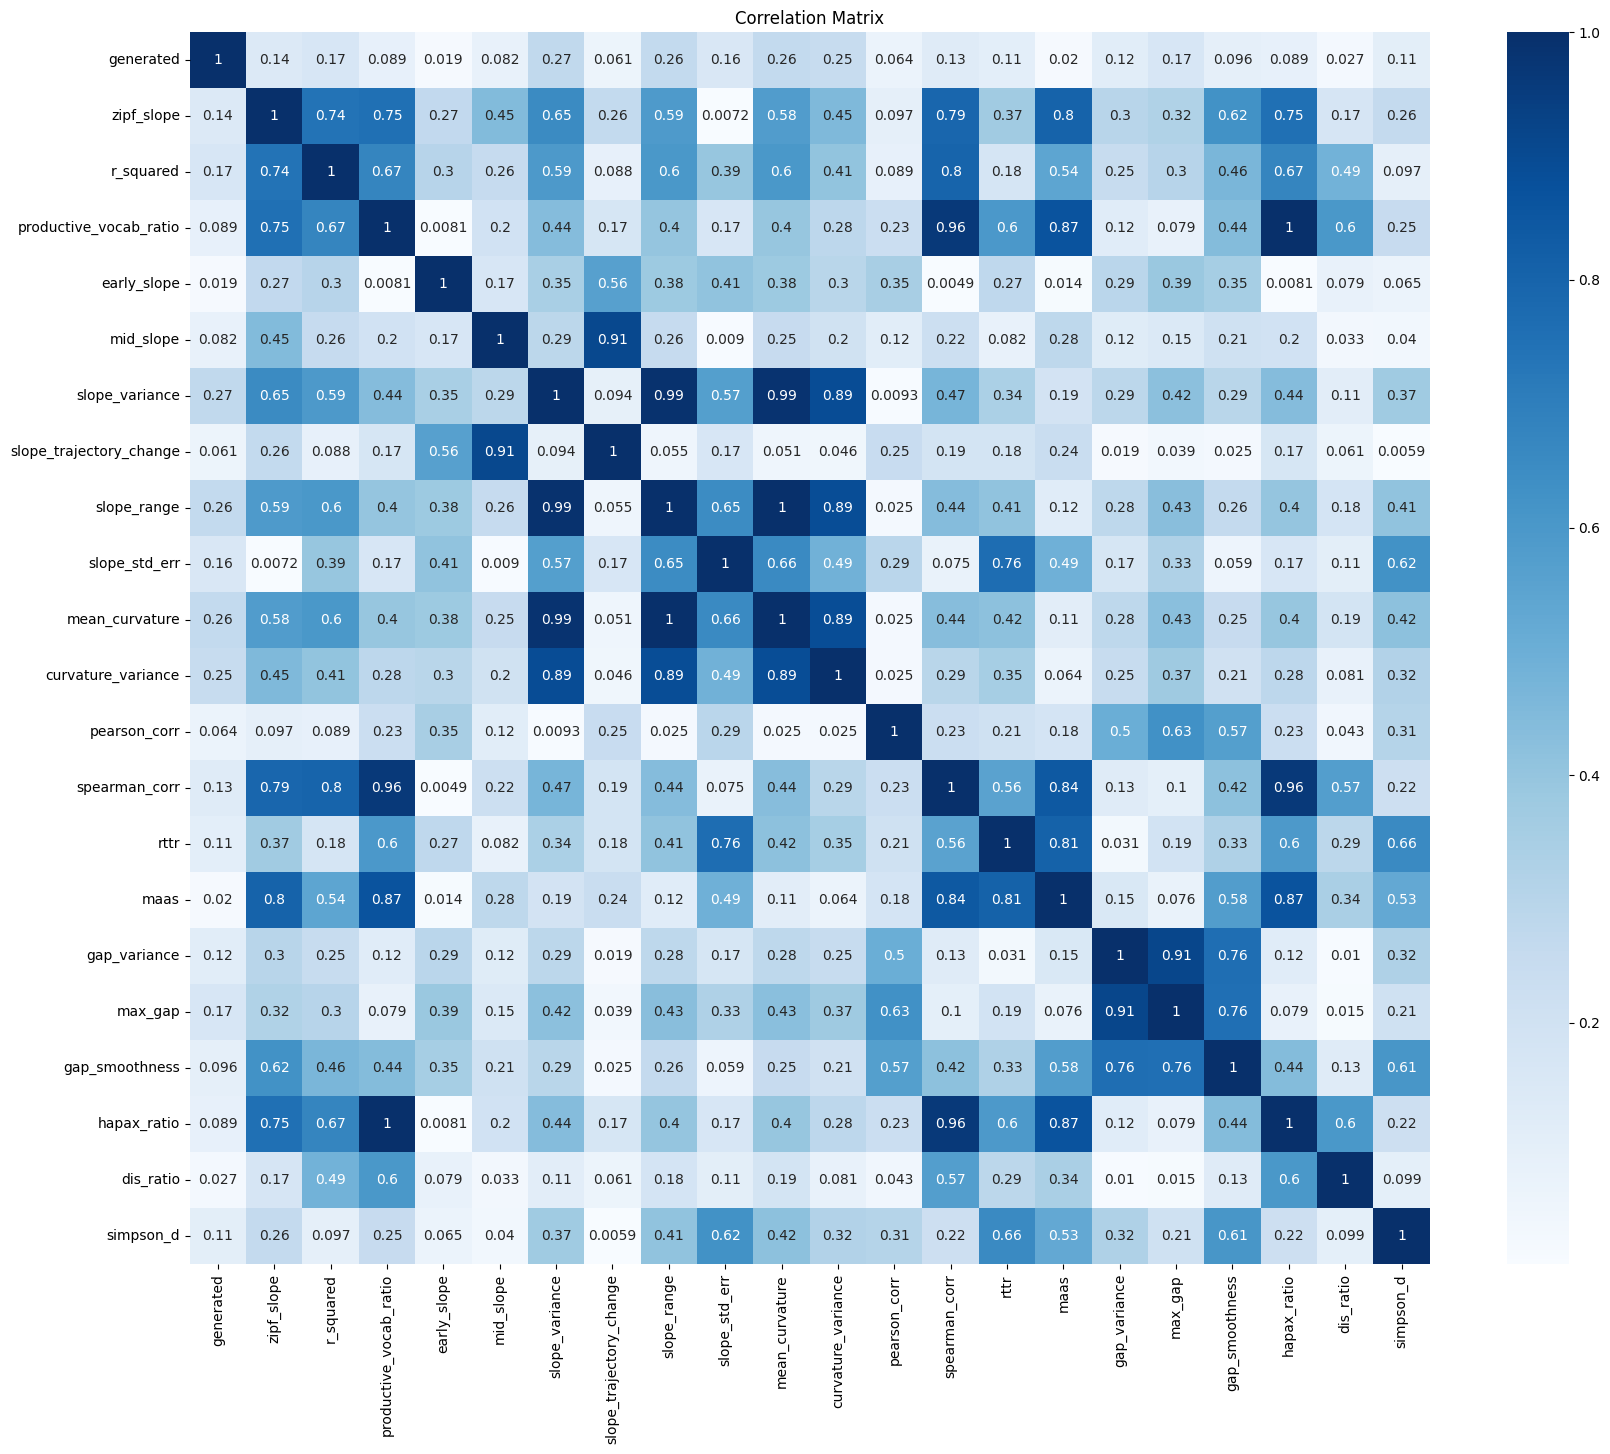

In [22]:
correlation_matrix = results_df.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', 
            xticklabels=results_df.columns, 
            yticklabels=results_df.columns)
plt.title('Correlation Matrix')
plt.show()

In [23]:
results_df.head()

,generated,zipf_slope,r_squared,productive_vocab_ratio,early_slope,mid_slope,slope_variance,slope_trajectory_change,slope_range,slope_std_err,...,pearson_corr,spearman_corr,rttr,maas,gap_variance,max_gap,gap_smoothness,hapax_ratio,dis_ratio,simpson_d
0,0,-0.742196,0.947732,0.430657,-0.903965,-0.672331,8.428694,-0.231633,20.795403,0.015001,...,0.984780,0.897674,7.530201,0.026204,2.154358,16.0,0.242647,0.569343,0.204380,0.023850
1,1,-0.517447,0.891251,0.329545,-0.374390,-0.608757,3.892086,0.234366,10.399234,0.019491,...,0.932393,0.831642,7.384796,0.019482,0.152464,3.0,0.091954,0.670455,0.181818,0.017953
2,0,-0.653075,0.919938,0.385621,-0.718076,-0.693668,8.542561,-0.024408,20.795403,0.015679,...,0.807332,0.872717,8.689816,0.021458,0.093447,2.0,0.072368,0.614379,0.176471,0.013111
3,1,-0.796337,0.921879,0.438710,-0.542084,-1.467119,10.677088,0.925036,23.914433,0.018741,...,0.802274,0.904437,7.683065,0.026738,0.119076,2.0,0.103896,0.561290,0.167742,0.014712
4,0,-0.658411,0.918763,0.376404,-0.434417,-1.074680,10.102668,0.640264,23.567873,0.014758,...,0.853410,0.867755,9.329735,0.020571,0.118038,3.0,0.079096,0.623596,0.157303,0.011336


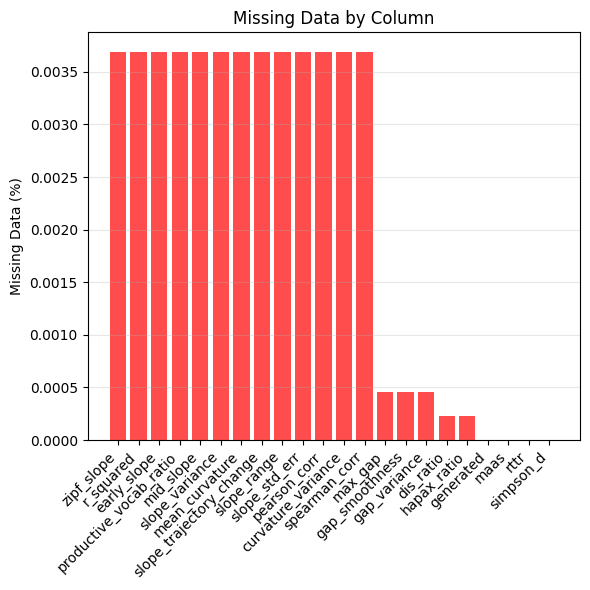

In [24]:
# missing data percentages
missing_data = (results_df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
colors = ['red' if x > 0 else 'lightgreen' for x in missing_data.values]
bars = plt.bar(range(len(missing_data)), missing_data.values, color=colors, alpha=0.7)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data by Column')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()




In [25]:
results_df.dropna(axis=0,inplace=True)

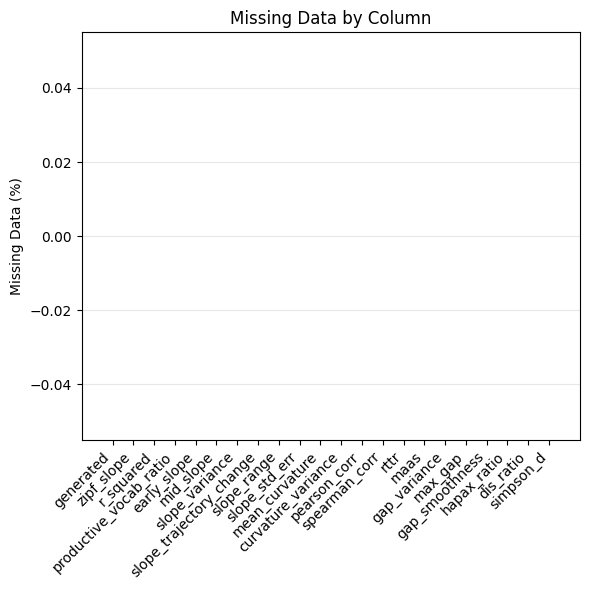

In [26]:
missing_data = (results_df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
colors = ['red' if x > 0 else 'lightgreen' for x in missing_data.values]
bars = plt.bar(range(len(missing_data)), missing_data.values, color=colors, alpha=0.7)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data by Column')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [29]:
results_df

,generated,zipf_slope,r_squared,productive_vocab_ratio,early_slope,mid_slope,slope_variance,slope_trajectory_change,slope_range,slope_std_err,...,pearson_corr,spearman_corr,rttr,maas,gap_variance,max_gap,gap_smoothness,hapax_ratio,dis_ratio,simpson_d
0,0,-0.742196,0.947732,0.430657,-0.903965,-0.672331,8.428694,-0.231633,20.795403,0.015001,...,0.984780,0.897674,7.530201,0.026204,2.154358,16.0,0.242647,0.569343,0.204380,0.023850
1,1,-0.517447,0.891251,0.329545,-0.374390,-0.608757,3.892086,0.234366,10.399234,0.019491,...,0.932393,0.831642,7.384796,0.019482,0.152464,3.0,0.091954,0.670455,0.181818,0.017953
2,0,-0.653075,0.919938,0.385621,-0.718076,-0.693668,8.542561,-0.024408,20.795403,0.015679,...,0.807332,0.872717,8.689816,0.021458,0.093447,2.0,0.072368,0.614379,0.176471,0.013111
3,1,-0.796337,0.921879,0.438710,-0.542084,-1.467119,10.677088,0.925036,23.914433,0.018741,...,0.802274,0.904437,7.683065,0.026738,0.119076,2.0,0.103896,0.561290,0.167742,0.014712
4,0,-0.658411,0.918763,0.376404,-0.434417,-1.074680,10.102668,0.640264,23.567873,0.014758,...,0.853410,0.867755,9.329735,0.020571,0.118038,3.0,0.079096,0.623596,0.157303,0.011336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86582,0,-0.785627,0.913032,0.388060,-0.525223,-1.219789,8.401005,0.694566,18.369522,0.021104,...,0.880595,0.876243,7.332154,0.027045,0.363050,5.0,0.142857,0.611940,0.134328,0.017785
86583,0,-0.747006,0.914848,0.477064,-0.580257,-1.108464,7.772460,0.528206,18.369522,0.022032,...,0.789962,0.920966,6.670692,0.028699,0.109997,2.0,0.101852,0.522936,0.201835,0.017492
86584,0,-0.570077,0.864473,0.255102,-0.529384,-0.925856,3.291358,0.396472,9.013271,0.023037,...,0.951043,0.764029,7.606275,0.020167,0.211500,3.0,0.123711,0.744898,0.142857,0.022717
86585,0,-0.639784,0.917259,0.329730,-0.652548,-0.802882,8.769216,0.150333,21.488517,0.014204,...,0.903906,0.833497,9.723384,0.019339,0.192551,4.0,0.092391,0.670270,0.156757,0.013247


In [27]:
results_df.to_csv('StatsNew.csv', index = False)

In [30]:
#feature selection & splitting the data
X=results_df.drop(['generated'],axis=1).copy()
y=results_df['generated'].copy()

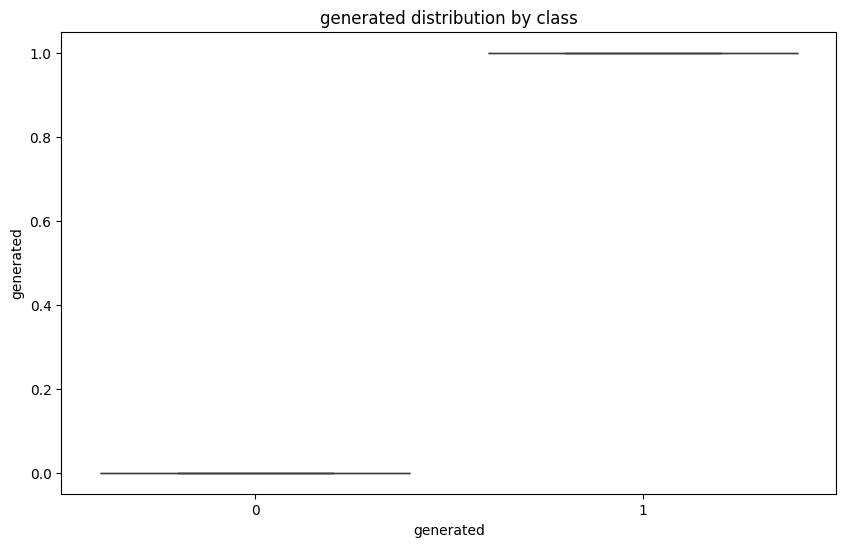

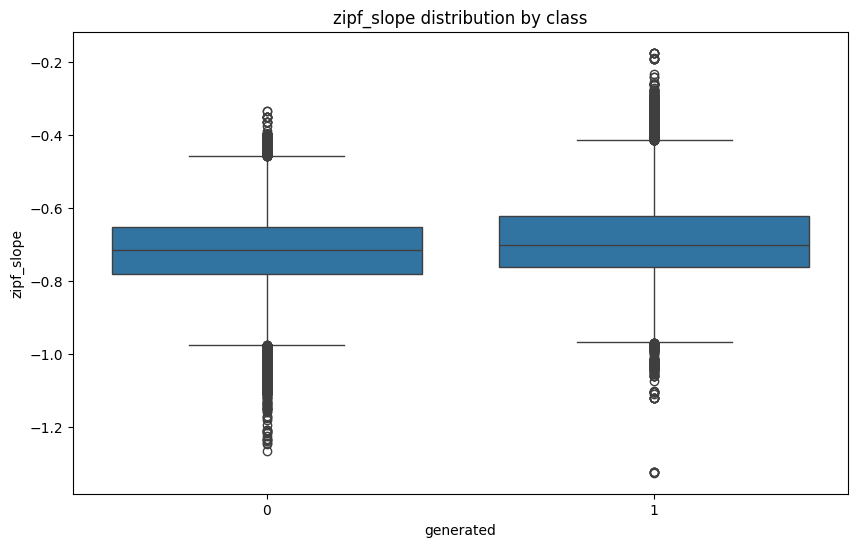

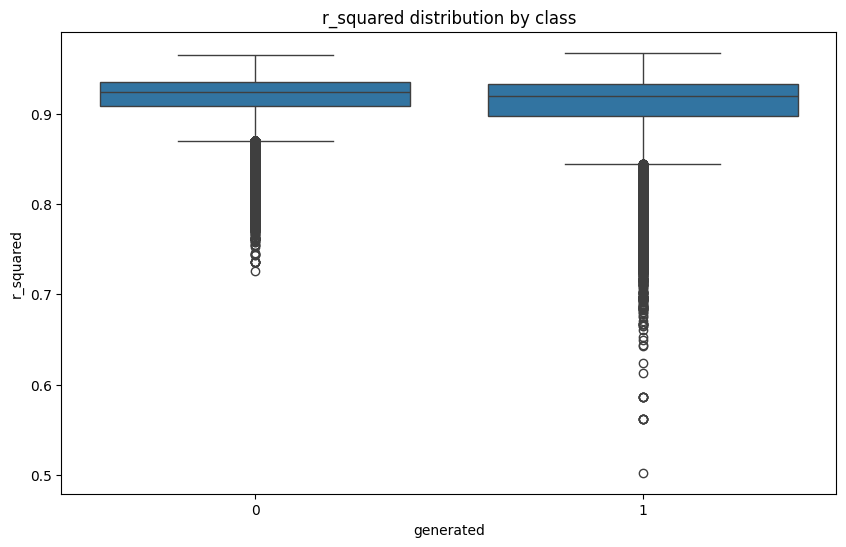

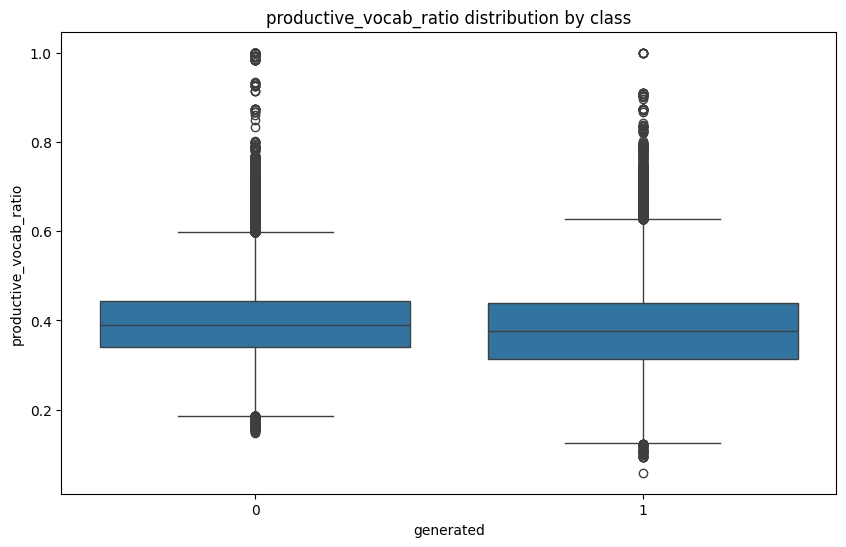

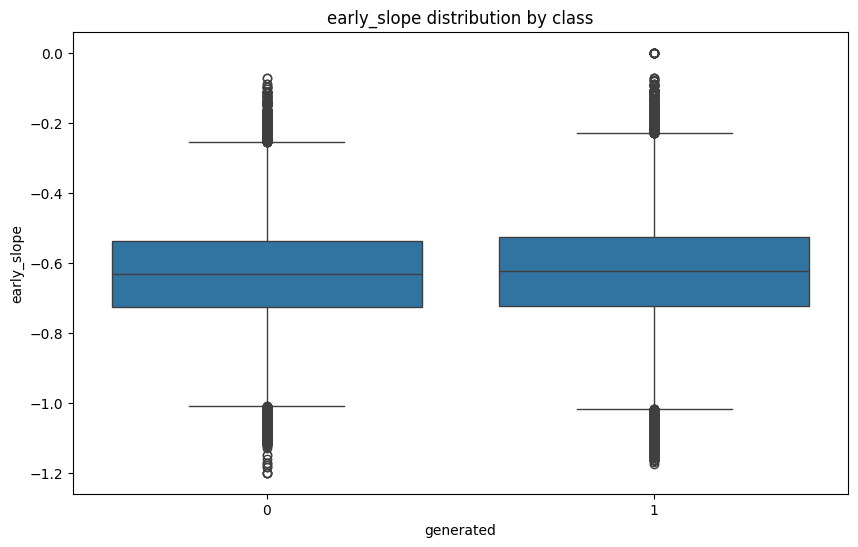

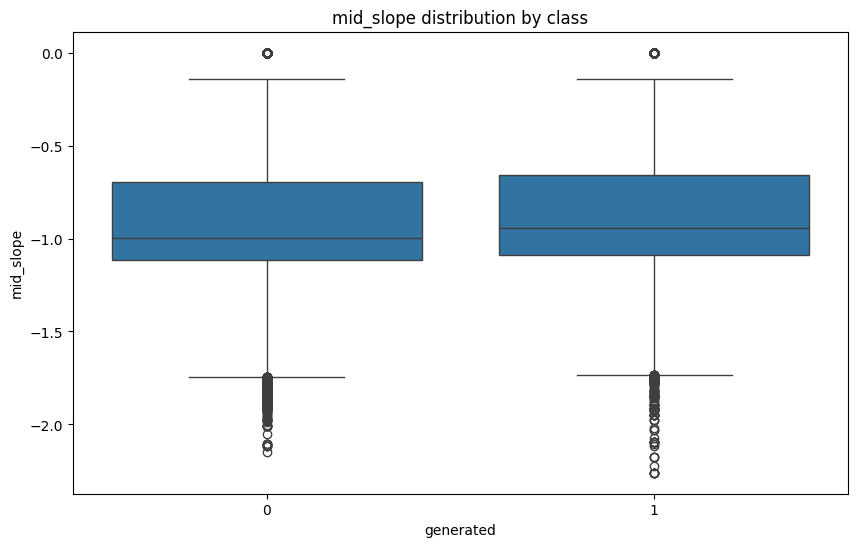

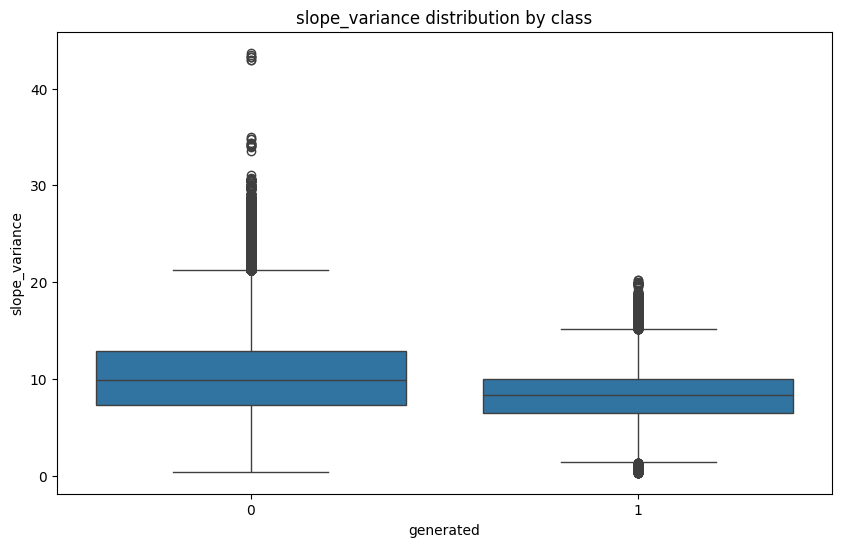

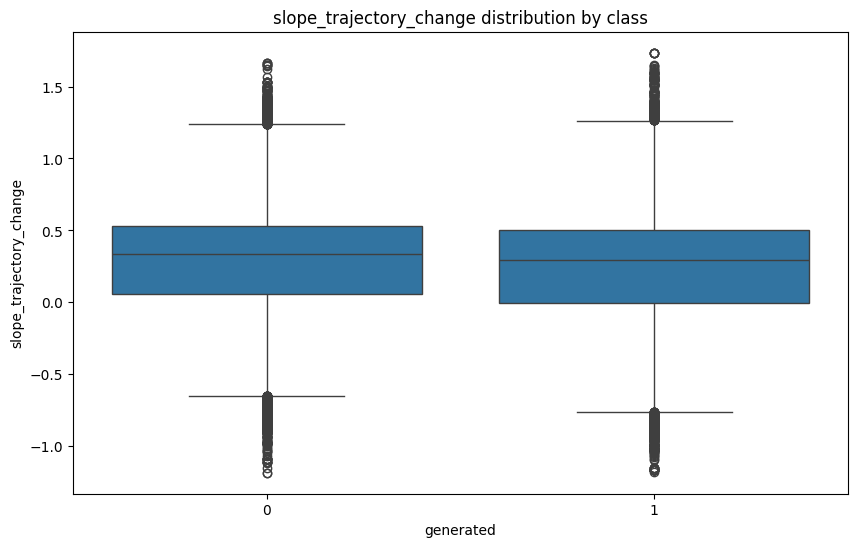

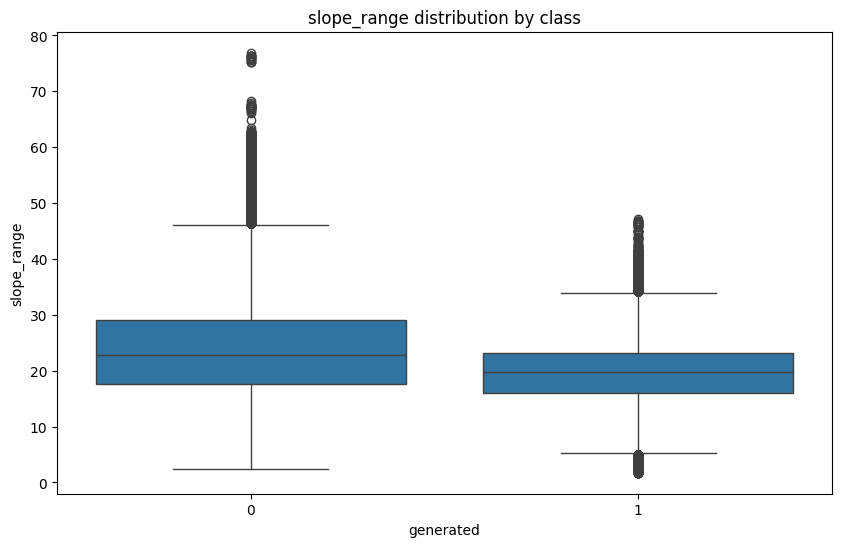

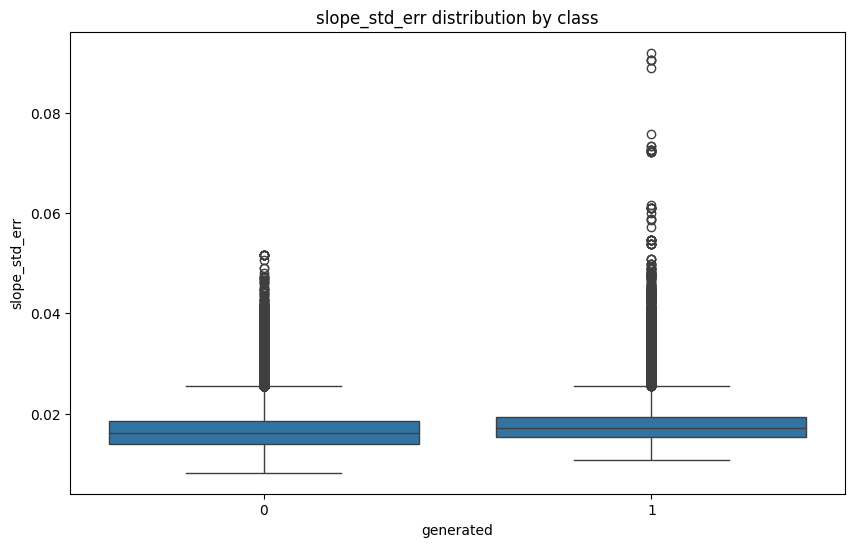

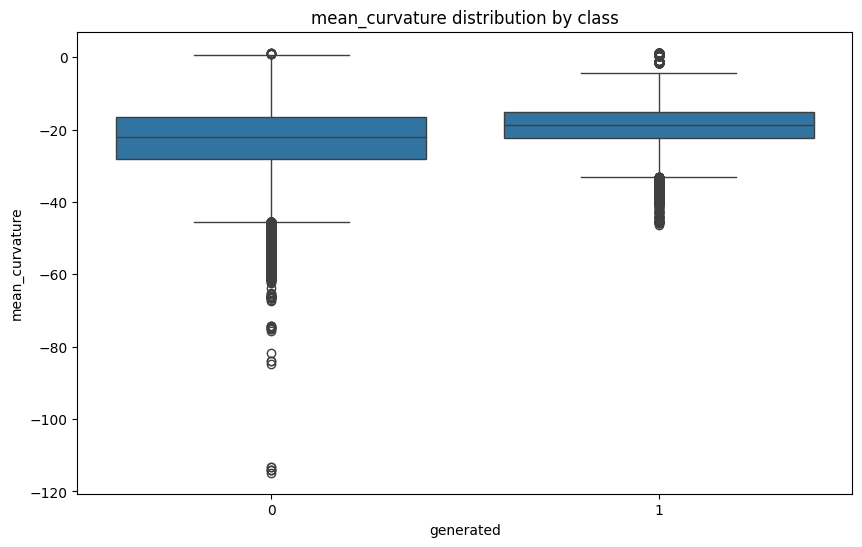

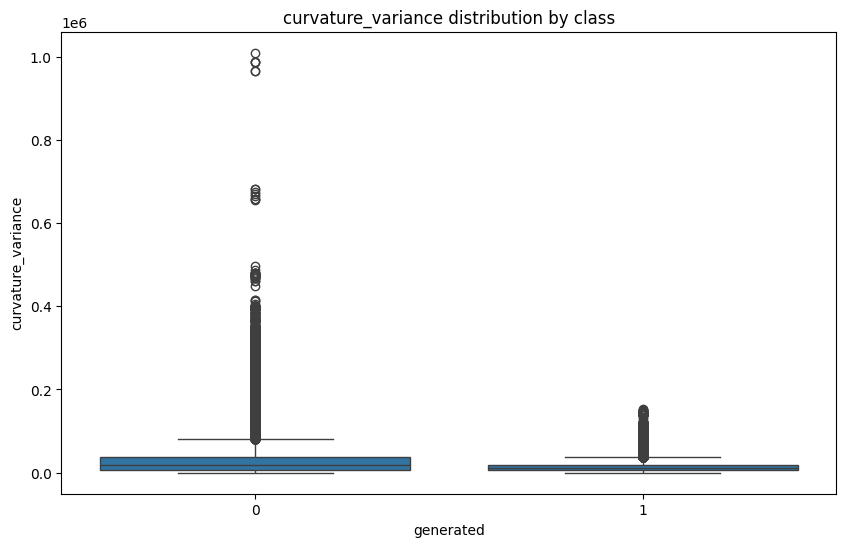

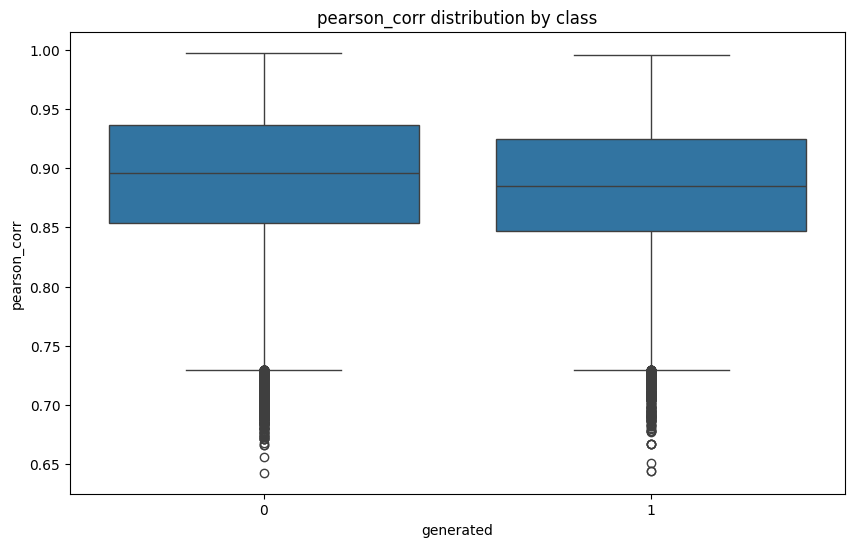

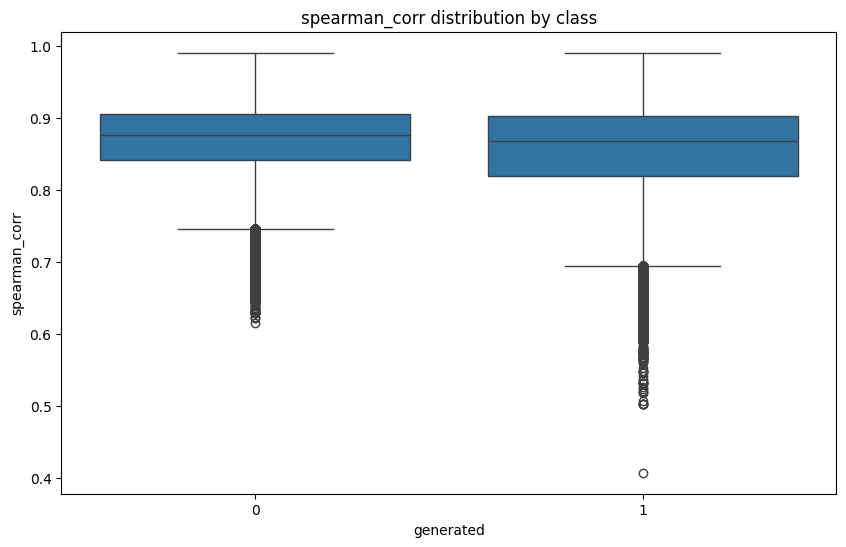

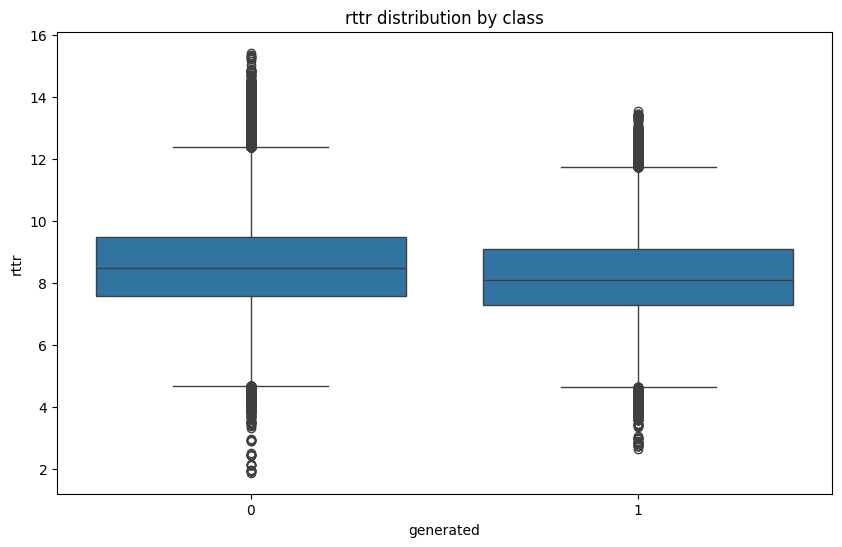

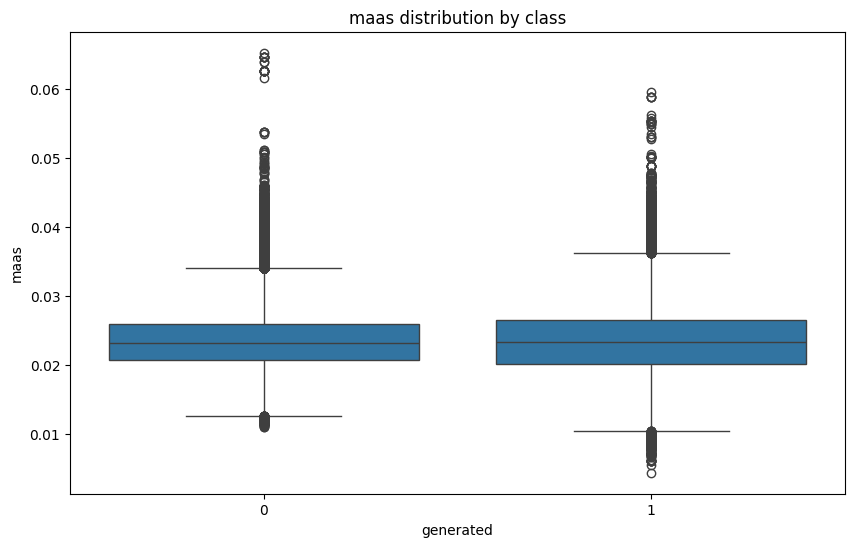

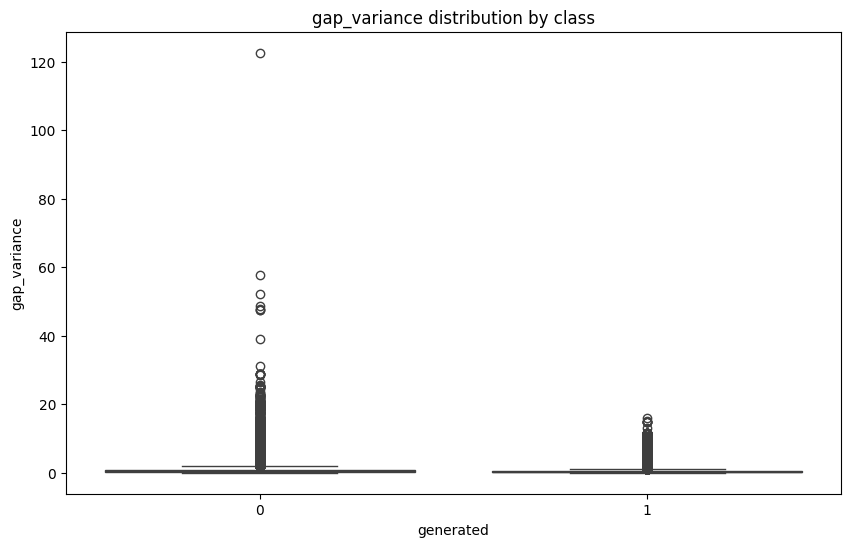

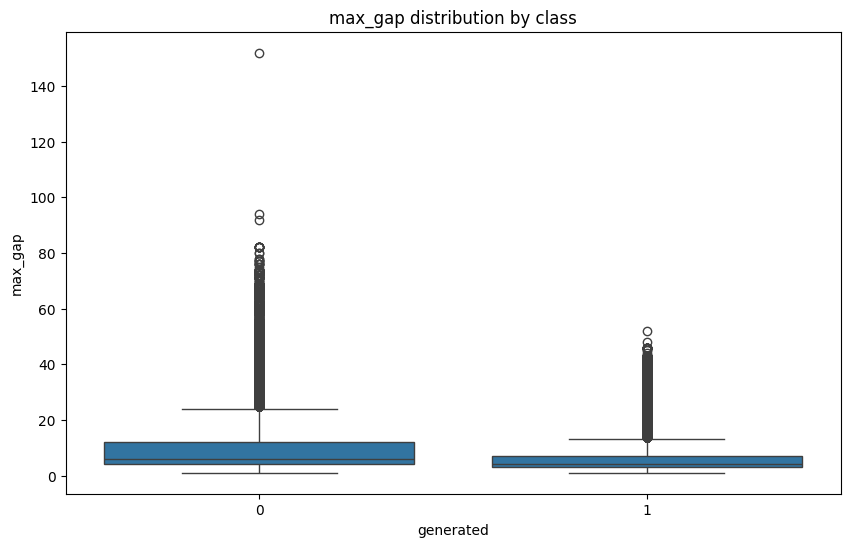

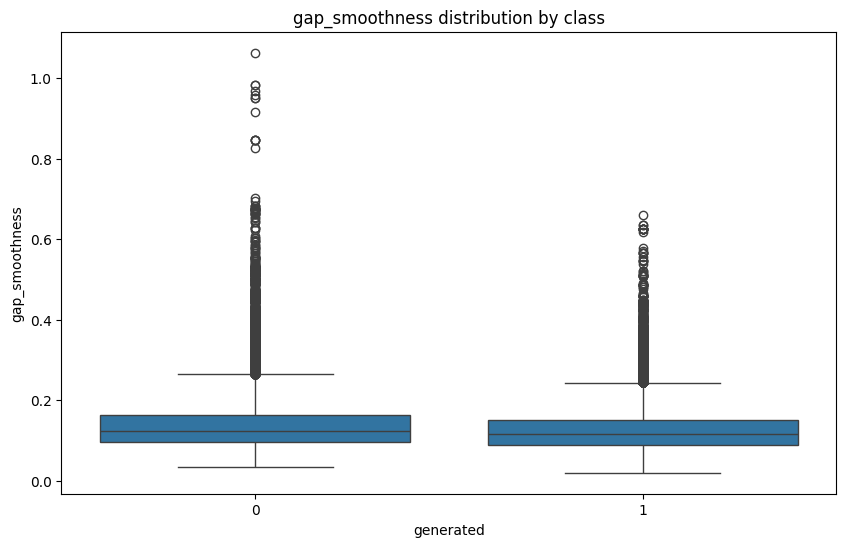

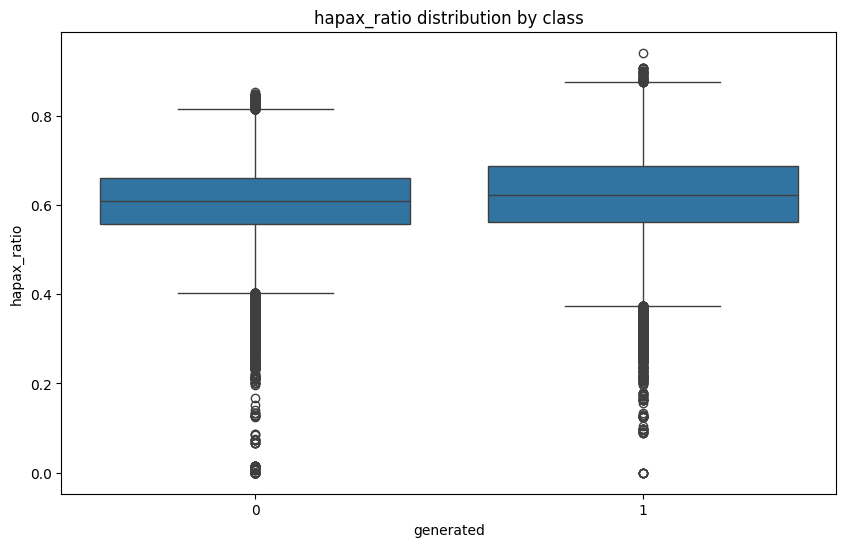

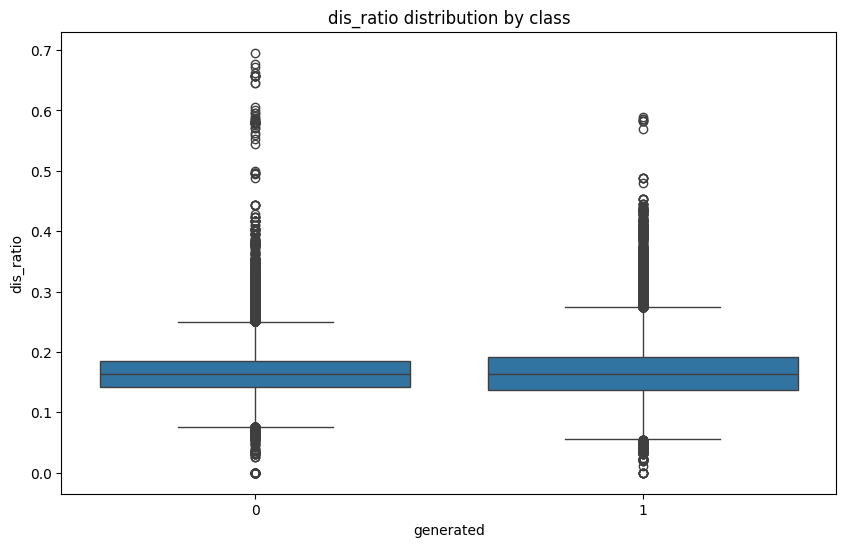

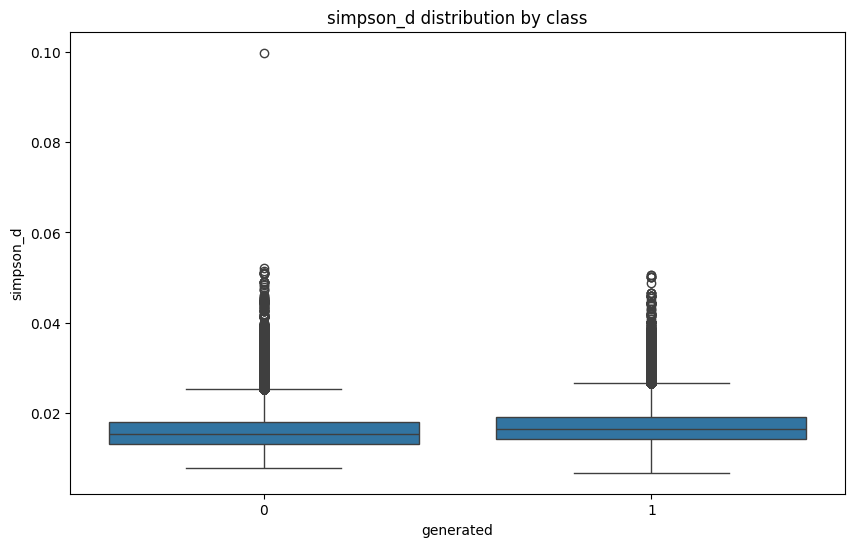

In [52]:
for feature in results_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=results_df, x='generated', y=feature)
    plt.title(f'{feature} distribution by class')
    plt.show()

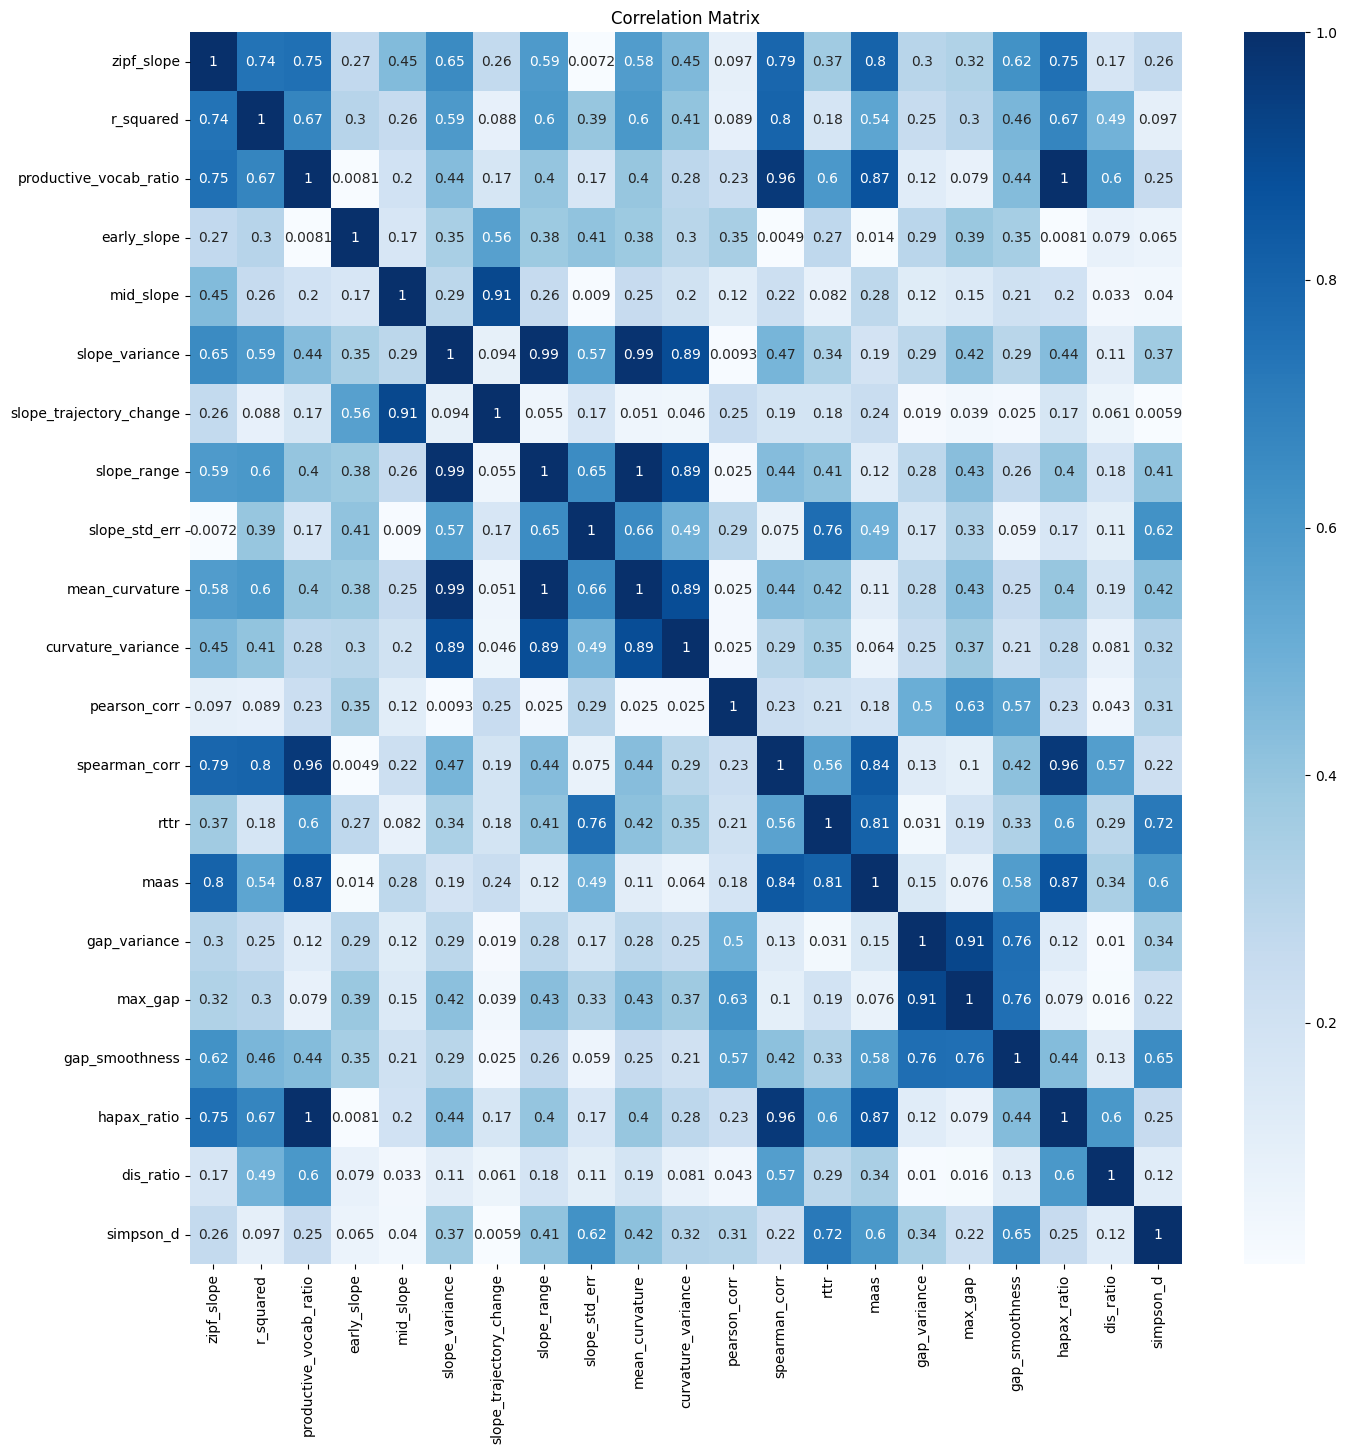

In [32]:
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', 
            xticklabels=X.columns, 
            yticklabels=X.columns)
plt.title('Correlation Matrix')
plt.show()

In [33]:
X.drop(['hapax_ratio','spearman_corr','slope_variance','max_gap','mid_slope','curvature_variance','maas'],axis=1,inplace=True)

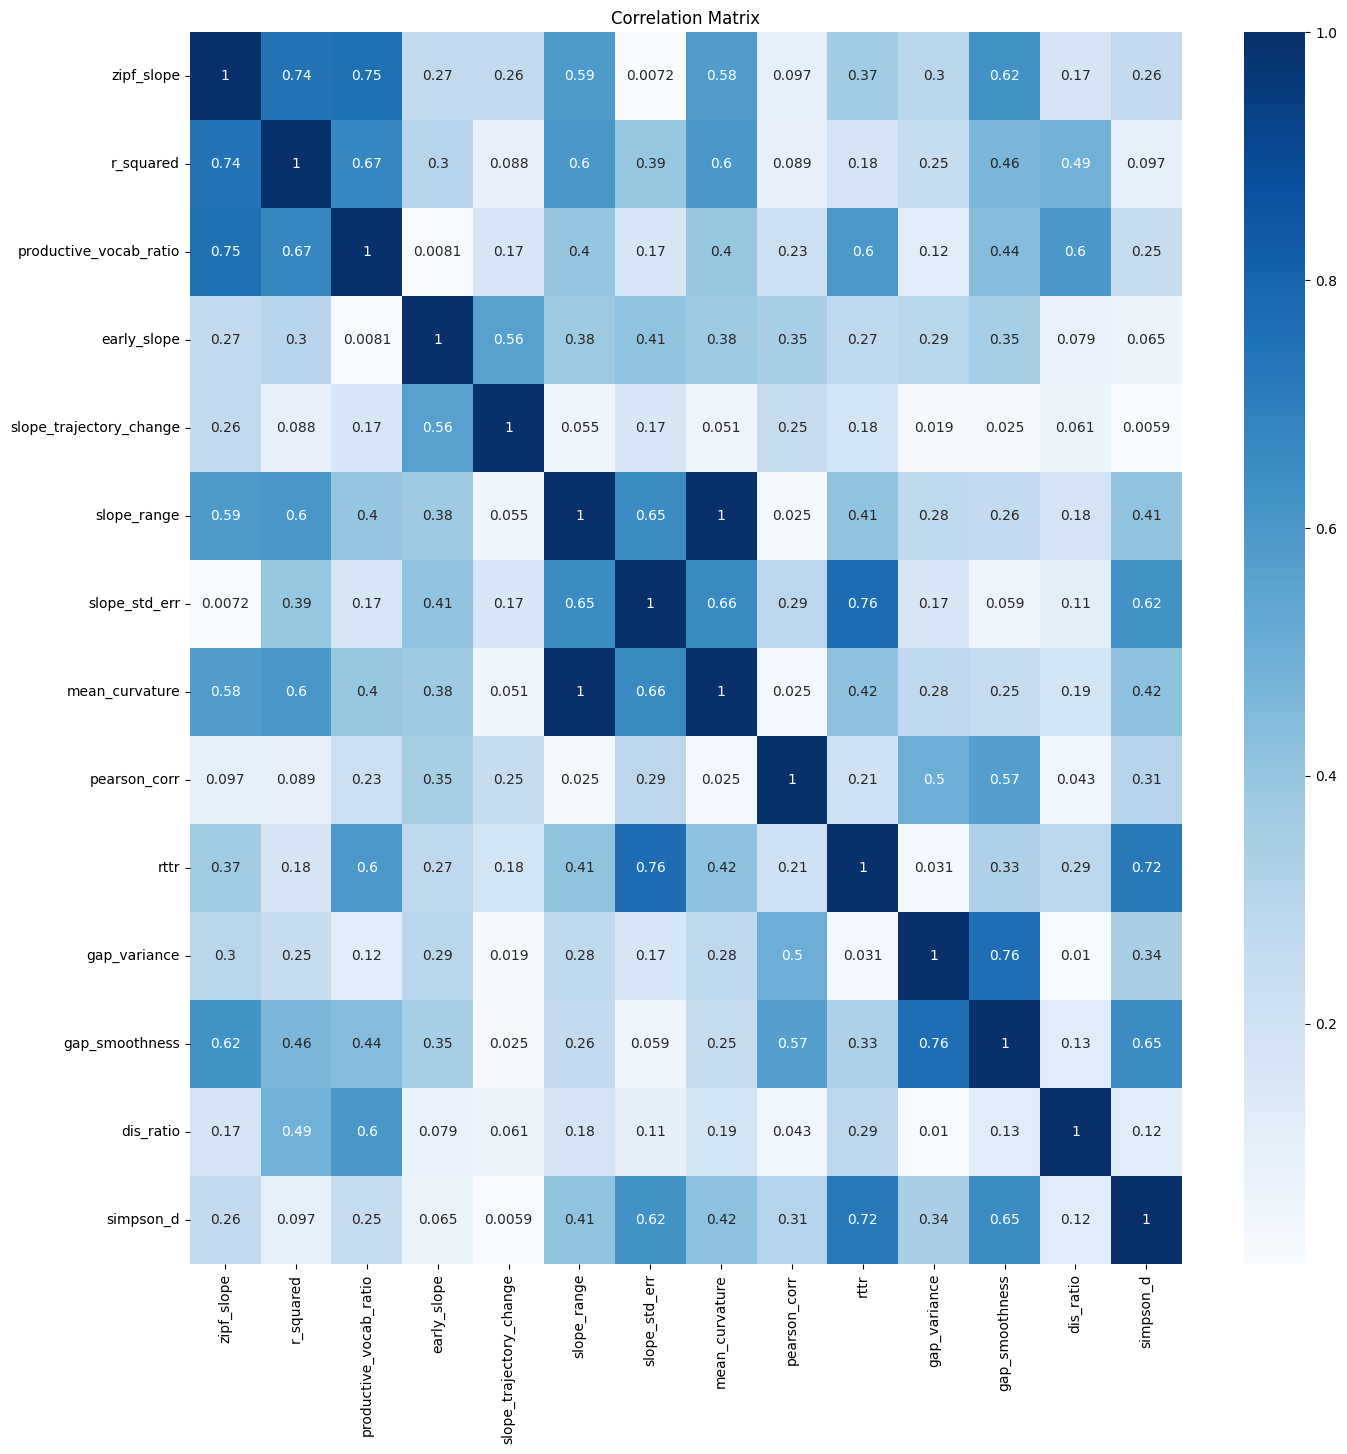

In [34]:
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', 
            xticklabels=X.columns, 
            yticklabels=X.columns)
plt.title('Correlation Matrix')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=101,n_jobs = -1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


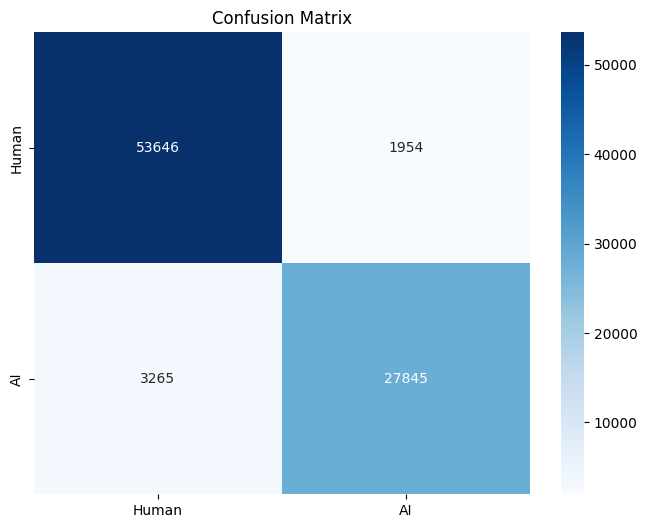

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human', 'AI'], 
            yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix')
plt.show()

In [38]:
print(classification_report(y_test, y_pred, 
                          target_names=['Human', 'AI']))

              precision    recall  f1-score   support

       Human       0.94      0.96      0.95     55600
          AI       0.93      0.90      0.91     31110

    accuracy                           0.94     86710
   macro avg       0.94      0.93      0.93     86710
weighted avg       0.94      0.94      0.94     86710



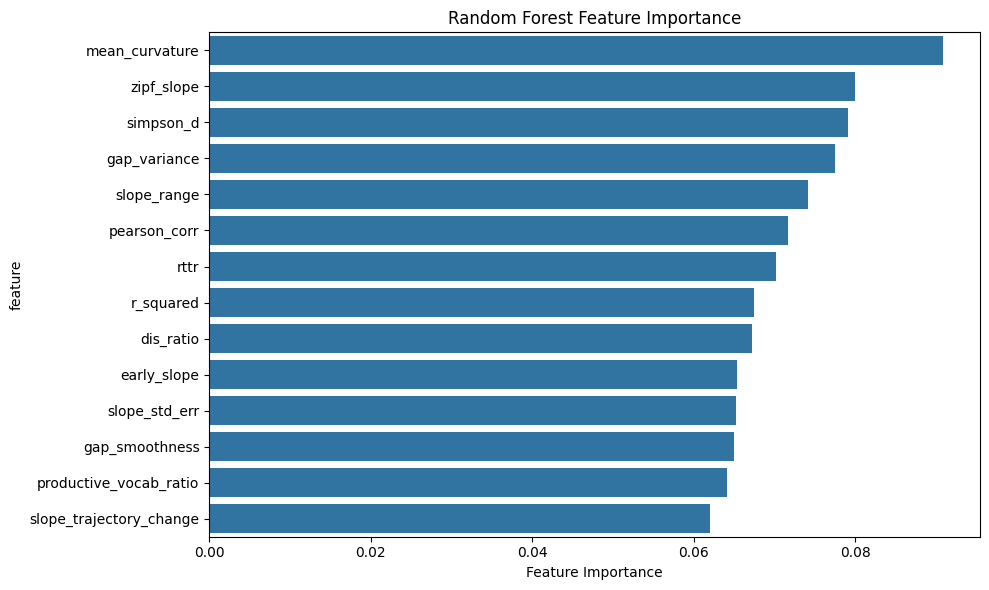

In [46]:
# feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance['importance'],y=feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()